# Financial Data Analysis with Alpha Vantage
**Objective:** Fetch, analyze, and visualize financial data using Alpha Vantage API.

Documentation : https://pypi.org/project/alpha-vantage/
---

## 0. Introduction & Setup

### A. Why Alpha Vantage?
- Free tier available
- Covers stocks, forex, crypto, and more
- Well-documented and reliable

### B. Get Your API Key
1. Sign up at [Alpha Vantage](https://www.alphavantage.co/support/#api-key).
2. Copy your free API key.
3. My API Key: B7PTXR7XMOXP7QAH

### C. Install Libraries
```bash
!pip install alpha_vantage
```

### D. Import Libraries

In [1]:
#!pip install alpha_vantage

#%pip install scipy

In [2]:
from alpha_vantage.timeseries import TimeSeries
from alpha_vantage.foreignexchange import ForeignExchange
from alpha_vantage.cryptocurrencies import CryptoCurrencies
from alpha_vantage.techindicators import TechIndicators
from alpha_vantage.fundamentaldata import FundamentalData
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import linregress

---

## 1. Basic Data Fetching

---



### A. Fetch Daily Stock Data

In [4]:
# Replace with your API key
api_key = 'B7PTXR7XMOXP7QAH'
ts = TimeSeries(key=api_key, output_format='pandas')
aapl_daily, meta_data = ts.get_daily('AAPL')
aapl_daily = aapl_daily.rename(columns={'1. open': 'Open', '2. high': 'High', '3. low': 'Low', '4. close': 'Close', '5. volume': 'Volume'})
aapl_daily = aapl_daily.sort_index(ascending=True)
aapl_daily.head()

,Open,High,Low,Close,Volume
date,,,,,
2025-06-06,203.00,205.70,202.0500,203.92,46607693.0
2025-06-09,204.39,206.00,200.0200,201.45,72862557.0
2025-06-10,200.60,204.35,200.5700,202.67,54672608.0
2025-06-11,203.50,204.50,198.4100,198.78,60989857.0
2025-06-12,199.08,199.68,197.3601,199.20,43904635.0


# Exercise:
Write a function that takes a dataframe as parameter and automatically renames the columns

In [6]:
def format_df(df):
    # Rename columns
    df = df.rename(columns={
        '1. open': 'Open',
        '2. high': 'High',
        '3. low': 'Low',
        '4. close': 'Close',
        '5. volume': 'Volume'
    })
    
    # Ensure index is datetime (important for stock data)
    df.index = pd.to_datetime(df.index)
    
    # Sort by date ascending
    df = df.sort_index(ascending=True)
    
    return df

### B. Basic Analysis & Visualization
* Plot the closing prices
* Calculate and plot the moving averages for 20 and 50 dates windows
  * hint: look at the 'rolling' and 'mean' functions in pandas
* Calculate and plot daily returns

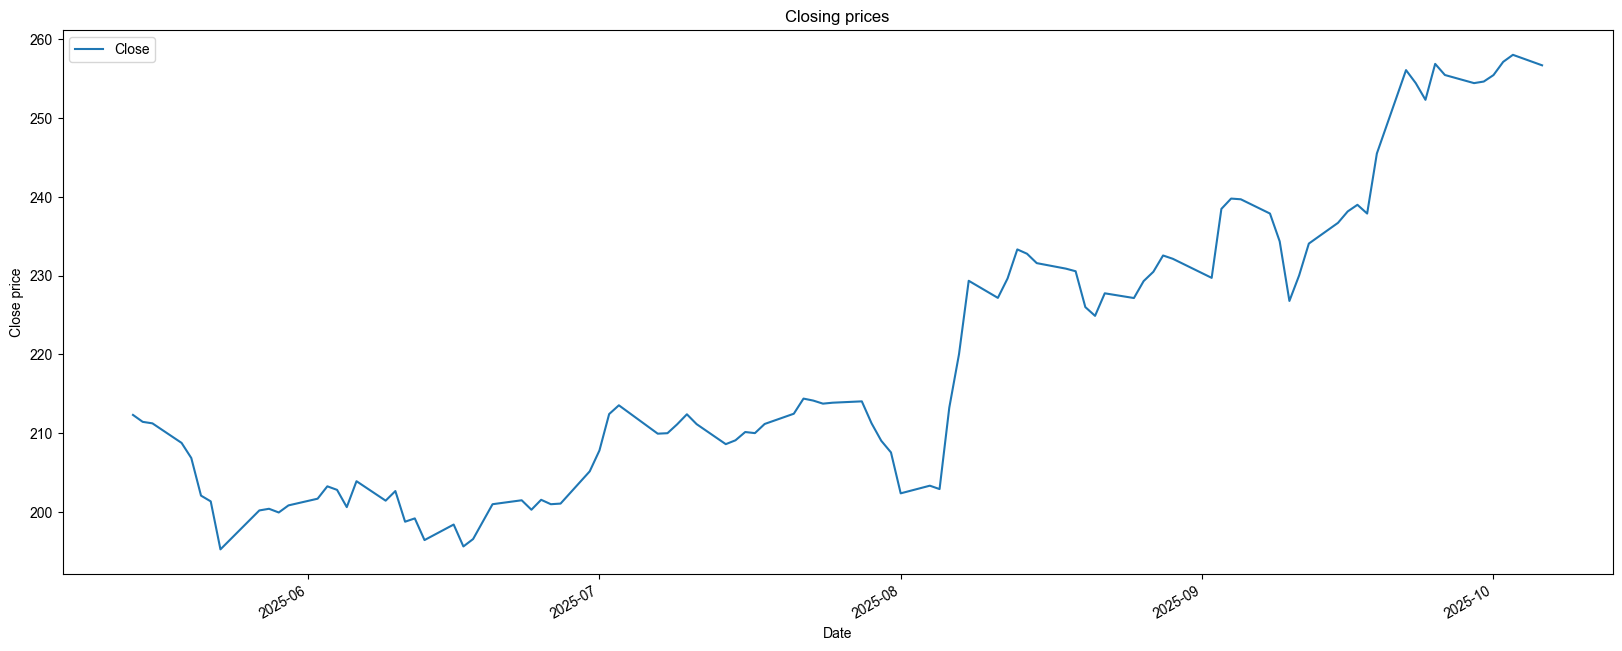

In [ ]:
# Plot closing price
aapl_daily.plot(y = 'Close', use_index=True, figsize=(20,8))

plt.title("Closing prices")

plt.xlabel("Date")
plt.ylabel("Close price")
sns.set_style("darkgrid")

plt.show()



In [21]:
# Calculate Moving averages

aapl_daily["avg20"] = aapl_daily["Close"].rolling(window=20).mean()
aapl_daily["avg50"] = aapl_daily["Close"].rolling(window=50).mean()

<Axes: xlabel='Daily', ylabel='Count'>

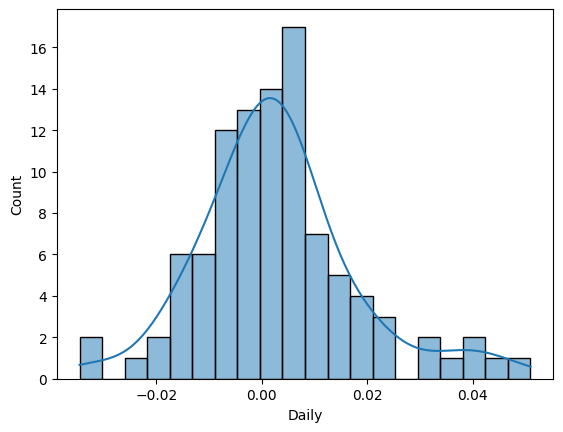

In [11]:
# Calculate daily returns
aapl_daily["Daily"] = aapl_daily["Close"].pct_change()

sns.histplot(aapl_daily["Daily"].dropna(), bins=20, kde=True)

---

## 2. Advanced Data Types

### A. Fetch Forex Data
* Get daily currency exchanges daily from EUR to USD
  * Use your function to format the dataframe
  * Plot the result

In [7]:
# Fetch data
fx = ForeignExchange(key=api_key, output_format='pandas')

forex_daily, meta_data = fx.get_currency_exchange_daily(from_symbol='EUR', to_symbol='USD')

forex_daily = format_df(forex_daily)

forex_daily.head()

,Open,High,Low,Close
date,,,,
2025-06-11,1.1426,1.1499,1.1404,1.1487
2025-06-12,1.1491,1.1631,1.1484,1.1583
2025-06-13,1.1581,1.1614,1.1488,1.1552
2025-06-16,1.1535,1.1614,1.1522,1.1561
2025-06-17,1.1566,1.1577,1.1474,1.1479


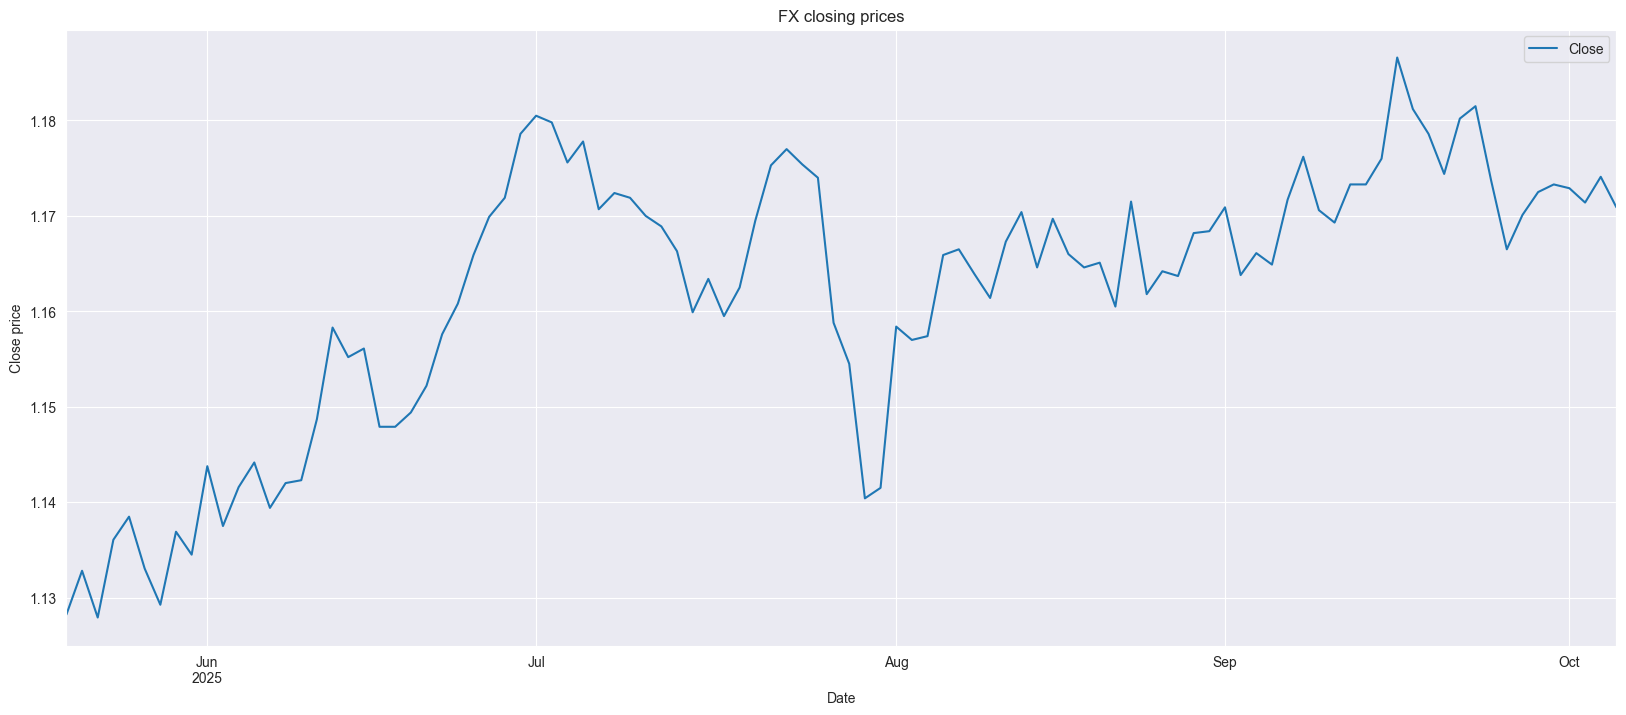

In [26]:
# Plot EUR/USD
forex_daily.plot(y = 'Close', use_index=True, figsize=(20,8))

plt.title("FX closing prices")

plt.xlabel("Date")
plt.ylabel("Close price")
sns.set_style("darkgrid")

plt.show()

### B. Fetch Crypto Data
* Retrieve Bitcoin digital currence ('BTC') in the 'USD' market
* Plot the closing prices

In [8]:
# Fetch BTC data
cc = CryptoCurrencies(key=api_key, output_format='pandas')

BTC_daily, meta_data = cc.get_digital_currency_daily(symbol='BTC', market='USD')

BTC_daily = format_df(BTC_daily)

BTC_daily.head()



,Open,High,Low,Close,Volume
date,,,,,
2024-11-14,90499.40,91831.25,86672.07,87340.40,23422.759159
2024-11-15,87338.96,91934.62,87100.83,91058.36,20388.331152
2024-11-16,91058.36,91820.73,90069.21,90636.24,6598.026930
2024-11-17,90638.54,91439.82,88713.64,89886.69,5574.551228
2024-11-18,89877.11,92674.80,89372.65,90520.30,17340.771665


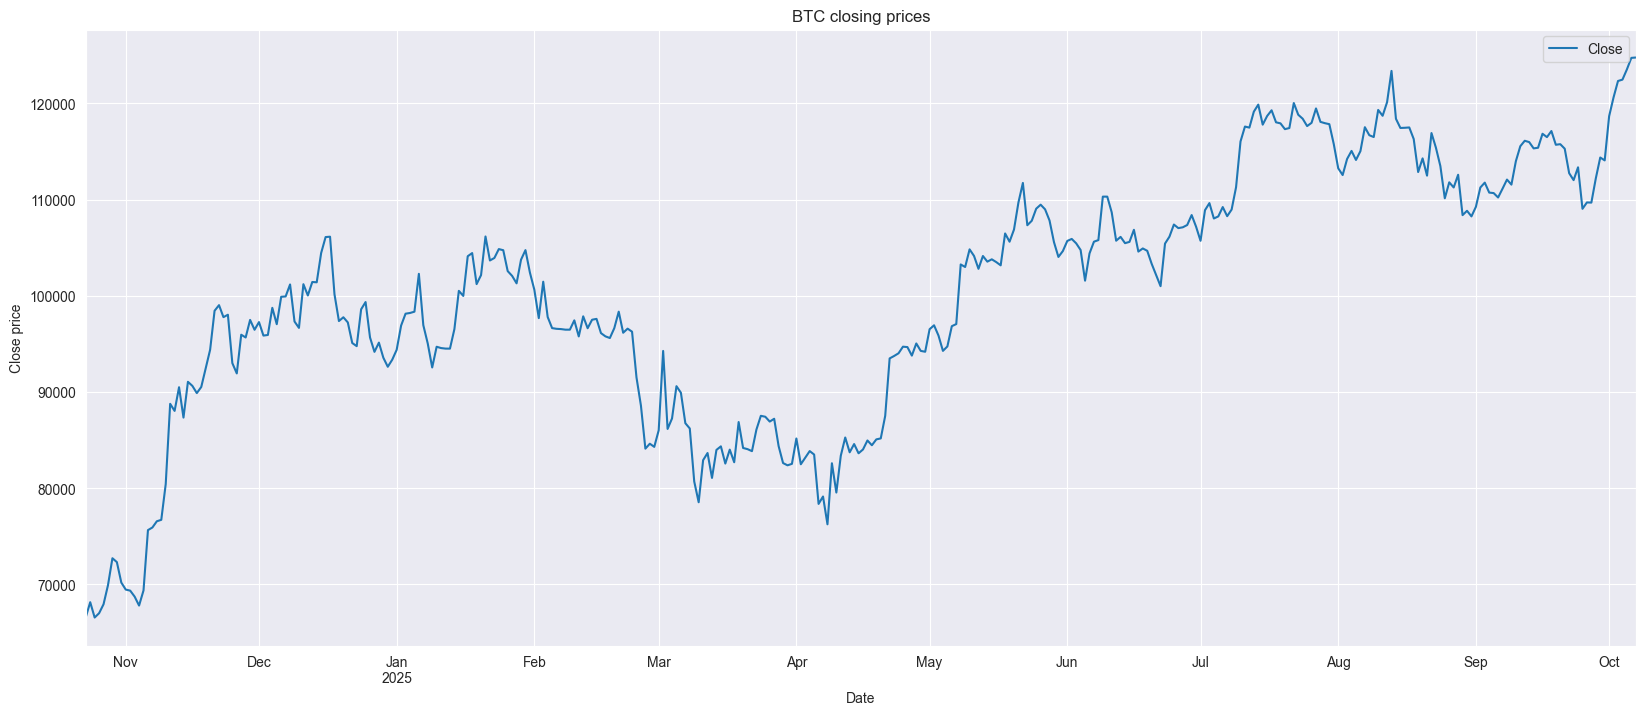

In [30]:
# Plot BTC/USD

BTC_daily.plot(y = 'Close', use_index=True, figsize=(20,8))

plt.title("BTC closing prices")

plt.xlabel("Date")
plt.ylabel("Close price")
sns.set_style("darkgrid")



### C. Fetch Technical Indicators (SMA, RSI, MACD)
* Retrieve the relative strength index (RSI) for Apple ('AAPL')
* Plot the result

In [9]:
# Fetch RSI
ti = TechIndicators(key=api_key, output_format = 'pandas')

aapl_rsi_daily, meta_data = ti.get_rsi(symbol='AAPL', interval='daily',time_period='14')

aapl_rsi_daily.head()

,RSI
date,
2025-10-28,69.1769
2025-10-27,69.0344
2025-10-24,64.1875
2025-10-23,61.1318
2025-10-22,60.0273


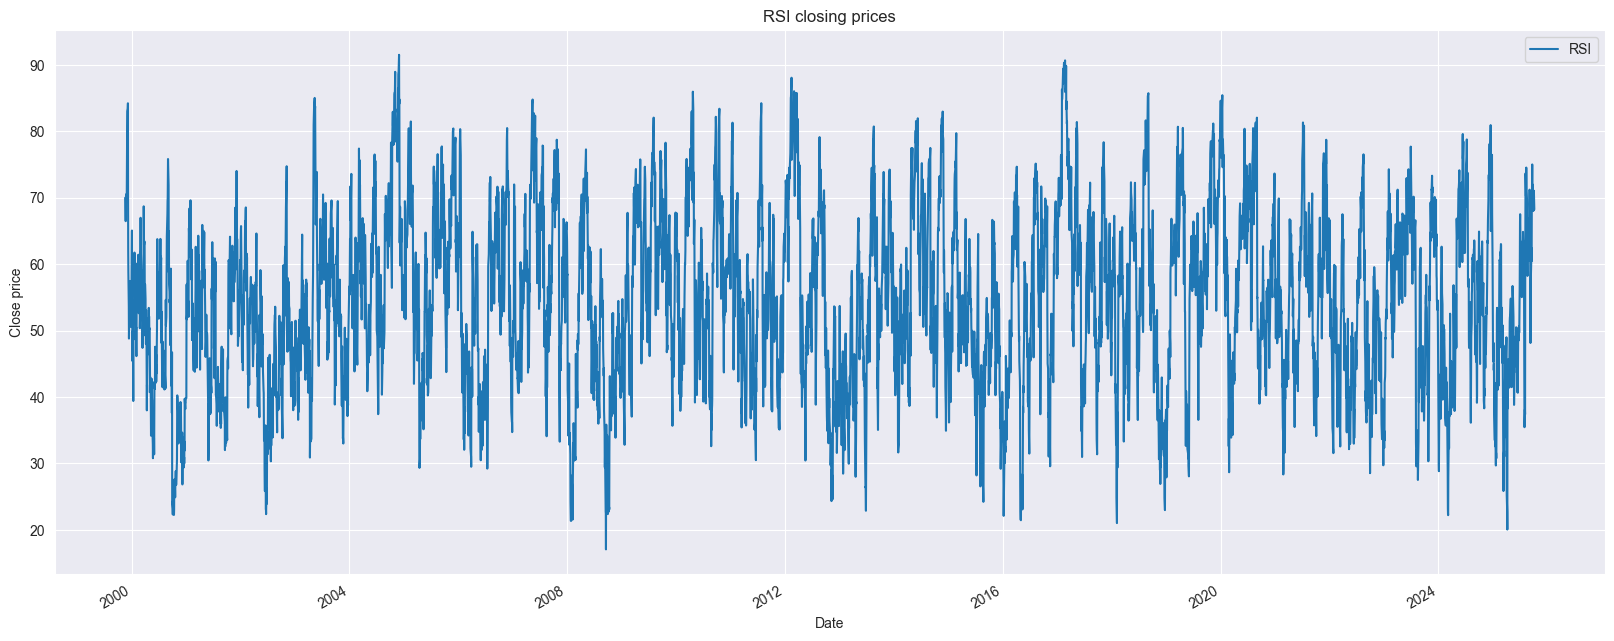

In [34]:
# Plot RSI

aapl_rsi_daily.plot(y = 'RSI', use_index = True, figsize=(20,8))

plt.title("RSI closing prices")

plt.xlabel("Date")
plt.ylabel("Close price")
sns.set_style("darkgrid")


---

## 3. Data Analysis & Visualization

### A. Correlation Analysis
* Retrieve some more daily stock data for comparison
  * Compute daily return
  * merge the two 'Daily return' columns from your two dataframes using pd.merge (relevant parameters: left_index=True, right_index=True, suffixes=('_sufx1', '_sufx2')
  * Drop all NaN rows and display result
  * Compute correlation using corr() on the merged df
  * Visualize the correlation using seaborn

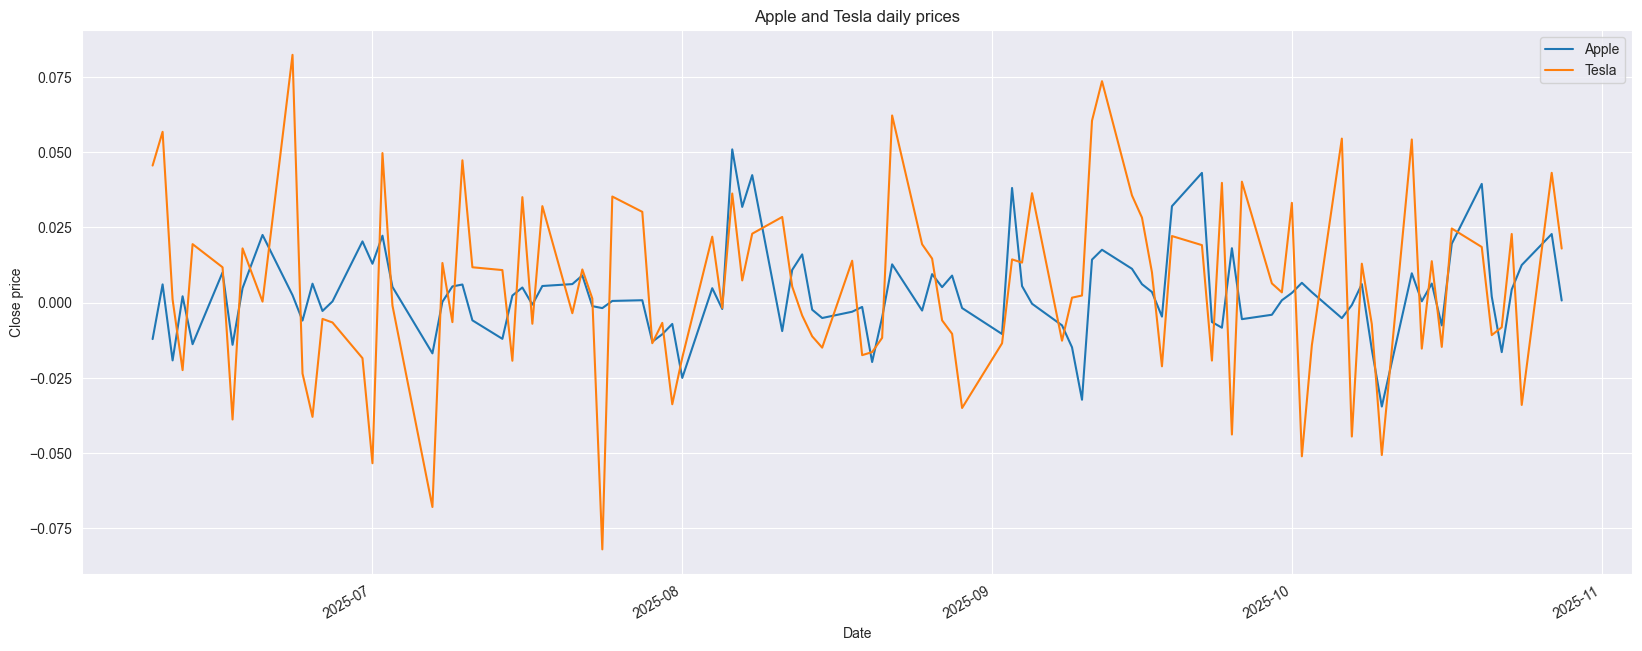

In [13]:
# Fetch  data for comparison
# Tesla
tsla_daily, tsla_meta = ts.get_daily('TSLA')
tsla_daily = format_df(tsla_daily)

# Amazon
amzn_daily, amzn_meta = ts.get_daily('AMZN')
amzn_daily = format_df(amzn_daily)

# Netflix
nflx_daily, nflx_meta = ts.get_daily('NFLX')
nflx_daily = format_df(nflx_daily)

# Calculate daily returns
tsla_daily["Daily"] = tsla_daily["Close"].pct_change()
amzn_daily["Daily"] = aapl_daily["Close"].pct_change()
nflx_daily["Daily"] = aapl_daily["Close"].pct_change()

nflx_daily.head()
# Merge daily returns
merge_aapl_tsla = pd.merge(left=aapl_daily["Daily"], right=tsla_daily["Daily"], left_index=True, right_index=True, suffixes=('_sufx1', '_sufx2'))

merge_aapl_tsla = merge_aapl_tsla.dropna()

merge_aapl_tsla[['Daily_sufx1', 'Daily_sufx2']].plot(figsize=(20, 8),title="Apple vs Tesla Daily Returns",)

plt.title("Apple and Tesla daily prices")

plt.xlabel("Date")
plt.ylabel("Close price")
plt.legend(["Apple", "Tesla"])
sns.set_style("darkgrid")

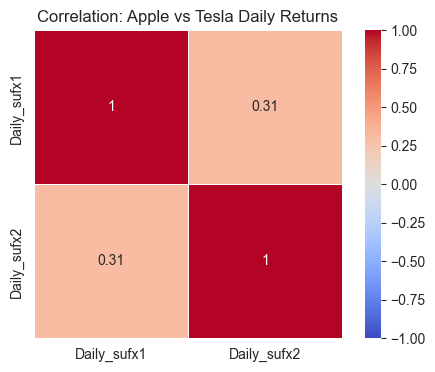

In [18]:
# Calculate correlation

aapl_tsla_corr = merge_aapl_tsla[['Daily_sufx1', 'Daily_sufx2']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(
    aapl_tsla_corr,
    annot=True,        # show the correlation values
    cmap="coolwarm",   # color map (you can try "viridis", "mako", "crest", etc.)
    vmin=-1, vmax=1,   # ensures consistent color scale
    linewidths=0.5,
    square=True
)

plt.title("Correlation: Apple vs Tesla Daily Returns")
plt.show()

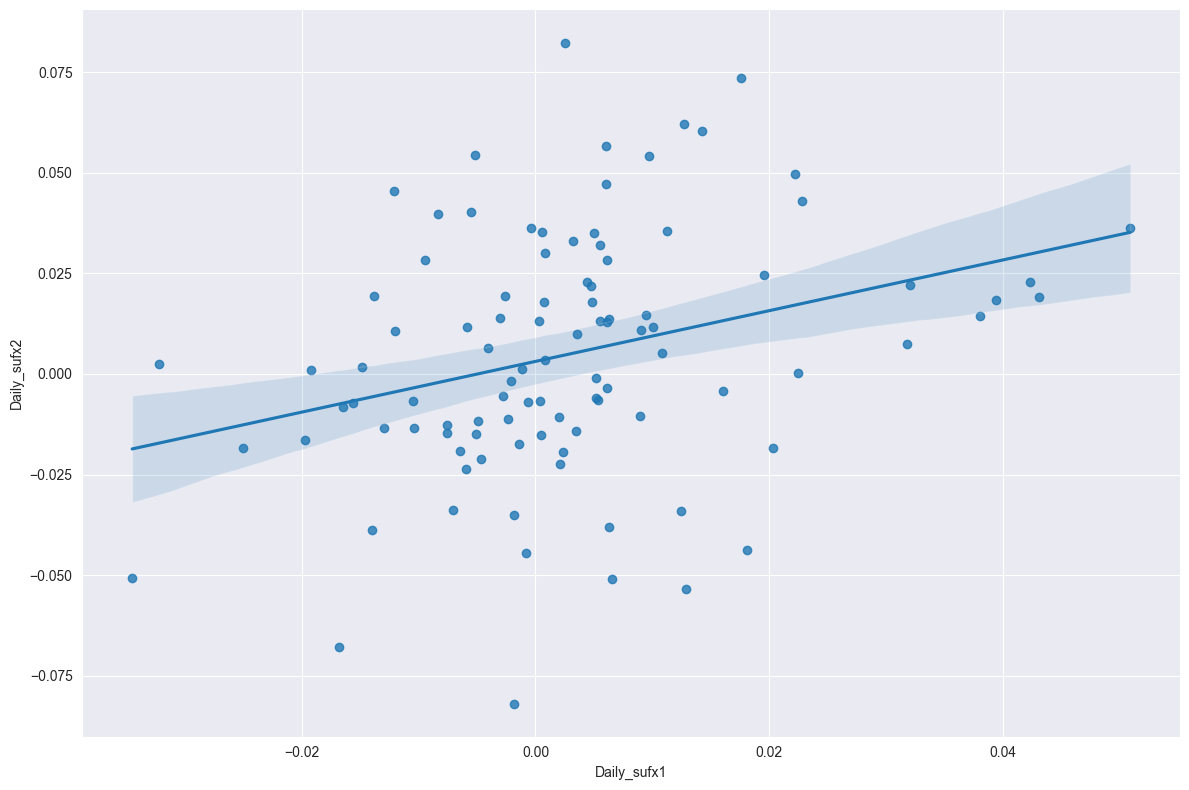

In [17]:
# Plot scatter and regression line
sns.lmplot(x='Daily_sufx1', y='Daily_sufx2', data=merge_aapl_tsla, height=8, aspect=1.5)